In [6]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [80]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


In [8]:
import pandas as pd
import json
import os

In [223]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
from sklearn.tree import export_graphviz
import graphviz
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

#### DISREGARD

Combining snp_matrix with lineages results to 22 samples only

In [30]:
import pandas as pd
import json
import os

snp_df = pd.read_csv("snp_matrix2.csv")  

json_folder = "./results"
lineage_data = []

for sample_id in snp_df['id']:
    json_path = os.path.join(json_folder, f"{sample_id}.results.json")
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            data = json.load(f)
            main_lineage = data.get("main_lineage", None)
            sub_lineage = data.get("sub_lineage", None)
            lineage_data.append({
                "id": sample_id,
                "main_lineage": main_lineage,
                "sub_lineage": sub_lineage
            })
    else:
        print(f"⛔ no JSON for sample: {sample_id}")

lineage_df = pd.DataFrame(lineage_data)

filtered_snp_df = snp_df[snp_df['id'].isin(lineage_df['id'])]

merged_df = pd.merge(filtered_snp_df, lineage_df, on="id", how="inner")

merged_df.to_csv("snp_with_lineage.csv", index=False)
print("✅ final merged dataset = snp_with_lineage.csv")


⛔ no JSON for sample: ERR046840
⛔ no JSON for sample: ERR067667
⛔ no JSON for sample: ERR067745
⛔ no JSON for sample: ERR137227
⛔ no JSON for sample: ERR2184331
⛔ no JSON for sample: ERR2184364
⛔ no JSON for sample: ERR2184415
⛔ no JSON for sample: ERR2184537
⛔ no JSON for sample: ERR2184562
⛔ no JSON for sample: ERR228008
⛔ no JSON for sample: ERR229956
⛔ no JSON for sample: ERR2510337
⛔ no JSON for sample: ERR2510362
⛔ no JSON for sample: ERR2510413
⛔ no JSON for sample: ERR2510446
⛔ no JSON for sample: ERR2510531
⛔ no JSON for sample: ERR2510564
⛔ no JSON for sample: ERR2510818
⛔ no JSON for sample: ERR2512608
⛔ no JSON for sample: ERR2512780
⛔ no JSON for sample: ERR2513280
⛔ no JSON for sample: ERR2513308
⛔ no JSON for sample: ERR2513479
⛔ no JSON for sample: ERR2513486
⛔ no JSON for sample: ERR2513827
⛔ no JSON for sample: ERR2513872
⛔ no JSON for sample: ERR2514132
⛔ no JSON for sample: ERR2514167
⛔ no JSON for sample: ERR2514198
⛔ no JSON for sample: ERR2514616
⛔ no JSON for sa

In [32]:
df = pd.read_csv("snp_with_lineage.csv")

print("Shape:", df.shape)

print("\ndf")
print(df.head())

Shape: (22, 10708)

df
           id  Chromosome_16_G_T  Chromosome_42_C_T  Chromosome_43_G_T  \
0  ERR2516329                  1                  0                  0   
1  ERR2516383                  0                  0                  0   
2  ERR4810602                  0                  0                  0   
3  ERR4810657                  0                  0                  0   
4  ERR4810775                  0                  0                  0   

   Chromosome_45_G_T  Chromosome_60_T_A  Chromosome_71_C_T  Chromosome_82_G_C  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  0   

   Chromosome_109_A_C  Chromosome_117_G_A  ..

---

## Pre-processing

Combining snp_matrices

In [25]:
snp1 = pd.read_csv("snp_matrix.csv")
snp2 = pd.read_csv("snp_matrix2.csv")
snp3 = pd.read_csv("snp_matrix3.csv")

# drop duplicate rows
combined_snp_df = pd.concat([snp1, snp2, snp3]).drop_duplicates(subset='id')

# separate id column for cleaning
id_col = combined_snp_df['id']
data = combined_snp_df.drop(columns=['id'])

# drop columns where values are all 0
non_zero_cols = (data.iloc[1:] != 0).any(axis=0)
data = data.loc[:, non_zero_cols]

# drop columns with any null/empty string values
no_missing_cols = ~data.isnull().any() & ~(data == '').any()
data = data.loc[:, no_missing_cols]

# add id col back again
final_df = pd.concat([id_col, data], axis=1)

final_df.to_csv("combined_snps.csv", index=False)
print(f"✅ combined_snps.csv created.\n Shape: {final_df.shape}")

✅ combined_snps.csv created.
 Shape: (263, 1719)


Combining snp_matrices with country and drug resistance pDST results for INH, RIF, PZA, and STM

In [30]:
snp_df = pd.read_csv("combined_snps.csv")
xl = pd.ExcelFile("master_data.xlsx")
meta_df = xl.parse("All", header=1)[["isolate name", "ena_run", "country"]]

target_drugs = ["ISONIAZID", "RIFAMPICIN", "PYRAZINAMIDE", "STREPTOMYCIN"]

for drug in target_drugs:
    if drug in xl.sheet_names:
        drug_df = xl.parse(drug)
        colname = f"{drug.lower()}_resistance"
        drug_df = drug_df.rename(columns={"resistance phenotype (pDST)": colname})
        drug_df[colname] = drug_df[colname].map({"R": 1, "S": 0})
        meta_df = meta_df.merge(drug_df[["isolate name", colname]], on="isolate name", how="left")
    else:
        print(f"⚠️ Sheet not found: {drug}")

# list IDs not found in master data
missing_ids = set(snp_df["id"]) - set(meta_df["ena_run"])
for mid in missing_ids:
    print(f"⛔ Not found in master data excel: {mid}")

final_df = snp_df.merge(meta_df, left_on="id", right_on="ena_run", how="inner")
final_df = final_df.drop(columns=["ena_run", "isolate name"])
final_df.to_csv("0_input.csv", index=False)

print(f"✅ 0_input.csv created.\n Shape: {final_df.shape}")

⛔ Not found in master data excel: ERR552933
⛔ Not found in master data excel: SRR2101226
⛔ Not found in master data excel: ERR4872232
⛔ Not found in master data excel: SRR2101303
⛔ Not found in master data excel: ERR551276
⛔ Not found in master data excel: SRR6831771
⛔ Not found in master data excel: ERR552394
⛔ Not found in master data excel: SRR6797692
⛔ Not found in master data excel: SRR6831724
⛔ Not found in master data excel: SRR6153245
⛔ Not found in master data excel: SRR6397445
⛔ Not found in master data excel: SRR6650306
⛔ Not found in master data excel: ERR550776
⛔ Not found in master data excel: SRR2100656
⛔ Not found in master data excel: SRR6797638
⛔ Not found in master data excel: SRR6832148
⛔ Not found in master data excel: SRR2024966
⛔ Not found in master data excel: SRR2100120
⛔ Not found in master data excel: SRR6152742
⛔ Not found in master data excel: SRR2024933
⛔ Not found in master data excel: ERR2199934
⛔ Not found in master data excel: SRR2101356
⛔ Not found in

In [32]:
print("\n")
print(final_df.head())



           id  Chromosome_82_G_C  Chromosome_109_A_C  Chromosome_267_A_C  \
0   ERR067667                  0                   0                   0   
1   ERR067745                  0                   0                   0   
2   ERR137227                  0                   0                   0   
3  ERR2184331                  0                   0                   0   
4  ERR2184364                  1                   0                   0   

   Chromosome_313_A_C  Chromosome_647_A_C  Chromosome_697_C_T  \
0                   0                   0                   0   
1                   0                   0                   0   
2                   0                   0                   0   
3                   0                   0                   0   
4                   0                   0                   0   

   Chromosome_1054_G_C  Chromosome_1058_T_G  Chromosome_1168_A_G  ...  \
0                    0                    0                    0  ...   
1   

In [55]:
print("Shape:", merged_df.shape)

print("\ndf")
print(merged_df.head())

Shape: (150, 8288)

df
           id  Chromosome_16_G_T  Chromosome_42_C_T  Chromosome_43_G_T  \
0   ERR067667                  0                  0                  0   
1   ERR067745                  0                  0                  0   
2   ERR137227                  0                  0                  0   
3  ERR2184331                  0                  0                  0   
4  ERR2184364                  0                  0                  0   

   Chromosome_45_G_T  Chromosome_60_T_A  Chromosome_71_C_T  Chromosome_82_G_C  \
0                  0                  0                  0                  0   
1                  0                  0                  0                  0   
2                  0                  0                  0                  0   
3                  0                  0                  0                  0   
4                  0                  0                  0                  1   

   Chromosome_109_A_C  Chromosome_117_G_A  ..

## Random Forest

Source: https://www.datacamp.com/tutorial/random-forests-classifier-python

### Isoniazid resistance prediction

In [233]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

INH_na = input_df['isoniazid_resistance'].isna().sum()
print("Missing values before drop:", INH_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['isoniazid_resistance'])

Missing values before drop: 21


In [235]:
columns_to_drop = ['rifampicin_resistance', 'pyrazinamide_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['isoniazid_resistance'] = input_df['isoniazid_resistance'].astype(int)

In [236]:
print("Shape after drop:", input_df.shape)

Shape after drop: (166, 1720)


#### Training

In [240]:
X = input_df.drop('isoniazid_resistance', axis=1)

# one-hot encoding country column
X = pd.get_dummies(X, columns=['country'])
y = input_df['isoniazid_resistance']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Shape of X (features): (166, 1734)
Shape of y (target): (166,)


In [241]:
print("Training feature shape:", X_train.shape)
print("Training label shape:", y_train.shape)
print("Testing feature shape:", X_test.shape)
print("Testing label shape:", y_test.shape)

Training feature shape: (132, 1734)
Training label shape: (132,)
Testing feature shape: (34, 1734)
Testing label shape: (34,)


In [292]:
rf = RandomForestClassifier(random_state=42)  
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [294]:
y_pred = rf.predict(X_test)

#### Performance metrics

In [297]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7878787878787878


In [298]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.75


In [299]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.3333333333333333


In [300]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.46153846153846156


In [301]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[23  1]
 [ 6  3]]


#### Tree visualization

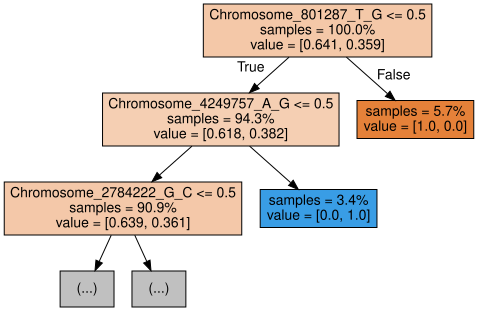

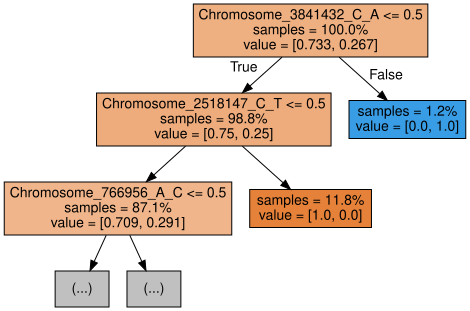

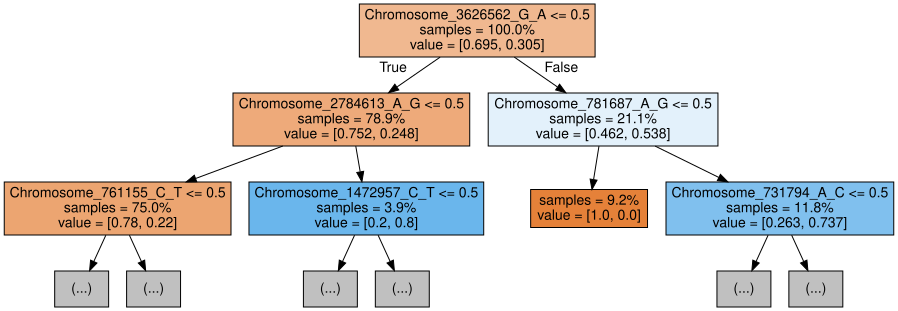

In [308]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_{i}", format="png", cleanup=True)

#### Feature importance

In [253]:
importances = rf.feature_importances_
features = X_train.columns

fi_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(fi_df)

                     Feature  Importance
739   Chromosome_2155168_C_G    0.087960
258    Chromosome_761155_C_T    0.059814
349    Chromosome_781687_A_G    0.047449
1558  Chromosome_4247429_A_G    0.020976
629   Chromosome_1673425_C_T    0.020940
...                      ...         ...
1075  Chromosome_3073880_C_A    0.000000
1076  Chromosome_3074033_G_T    0.000000
1077  Chromosome_3074139_C_T    0.000000
1078  Chromosome_3074408_T_C    0.000000
334    Chromosome_778905_T_C    0.000000

[1734 rows x 2 columns]


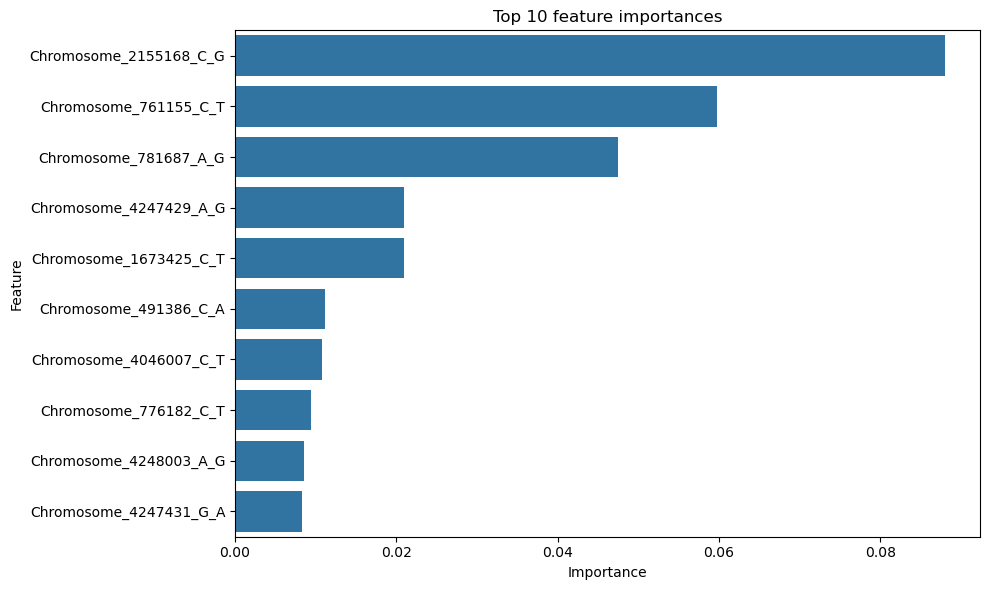

In [254]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df.head(10))
plt.title('Top 10 feature importances')
plt.tight_layout()
plt.show()

In [256]:
threshold = 1e-3
near_zero_fi = fi_df[fi_df['Importance'] < threshold]['Feature'].tolist()
print(f"{len(near_zero_fi)} features have importance < {threshold}")

1494 features have importance < 0.001


**note to self: find recommended threshold (rrl)**

#### Hyperparameter Tuning

Source: https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/

In [268]:
param_grid = {
    'n_estimators': [300, 500, 800, 1000, 1200], 
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'bootstrap': True, 'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 500}
Best Estimator: RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=500)


In [269]:
grid_search.fit(X_train, y_train)
updated_model = grid_search.best_estimator_
y_pred = updated_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        22
           1       1.00      0.58      0.74        12

    accuracy                           0.85        34
   macro avg       0.91      0.79      0.82        34
weighted avg       0.88      0.85      0.84        34



In [270]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_distributions = {
    'n_estimators': [300, 500, 800, 1000, 1200],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True]
}

random_search = RandomizedSearchCV(RandomForestClassifier(), param_distributions=param_distributions, cv=5)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Estimator:", random_search.best_estimator_)

Best Parameters: {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None, 'bootstrap': True}
Best Estimator: RandomForestClassifier(min_samples_leaf=2, n_estimators=800)


In [272]:
random_search.fit(X_train, y_train)
updated_model = random_search.best_estimator_
y_pred = updated_model.predict(X_test)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      1.00      0.90        22
           1       1.00      0.58      0.74        12

    accuracy                           0.85        34
   macro avg       0.91      0.79      0.82        34
weighted avg       0.88      0.85      0.84        34



### Rifampicin resistance prediction

In [280]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

RIF_na = input_df['rifampicin_resistance'].isna().sum()
print("Missing values before drop:", RIF_na)

# drop rows where resistance is missing
input_df = input_df.dropna(subset=['rifampicin_resistance'])

Missing values before drop: 23


In [282]:
columns_to_drop = ['isoniazid_resistance', 'pyrazinamide_resistance', 'streptomycin_resistance']
input_df = input_df.drop(columns=columns_to_drop, errors='ignore')

# convert float to int
input_df['rifampicin_resistance'] = input_df['rifampicin_resistance'].astype(int)

In [284]:
print("Shape after drop:", input_df.shape)

Shape after drop: (164, 1720)


#### Training

In [288]:
X = input_df.drop('rifampicin_resistance', axis=1)

# one-hot encoding country column
X = pd.get_dummies(X, columns=['country'])
y = input_df['rifampicin_resistance']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Shape of X (features): (164, 1733)
Shape of y (target): (164,)


In [290]:
print("Training feature shape:", X_train.shape)
print("Training label shape:", y_train.shape)
print("Testing feature shape:", X_test.shape)
print("Testing label shape:", y_test.shape)

Training feature shape: (131, 1733)
Training label shape: (131,)
Testing feature shape: (33, 1733)
Testing label shape: (33,)


In [98]:
rf = RandomForestClassifier(random_state=42)  
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [100]:
y_pred = rf.predict(X_test)

#### Performance metrics

In [103]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7878787878787878


In [105]:
precision = precision_score(y_test, y_pred)
print("Precision:", precision)

Precision: 0.75


In [107]:
recall = recall_score(y_test, y_pred)
print("Recall:", recall)

Recall: 0.3333333333333333


In [108]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.46153846153846156


In [111]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[23  1]
 [ 6  3]]


#### Tree visualization

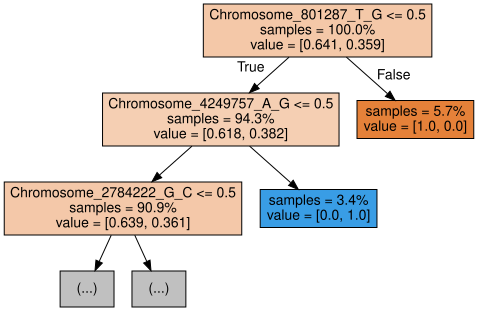

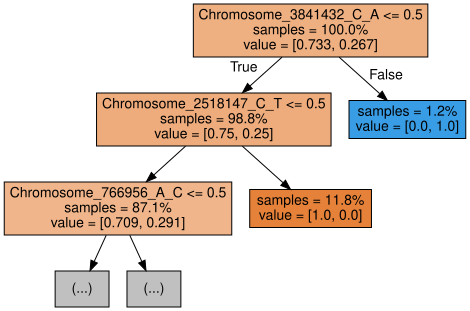

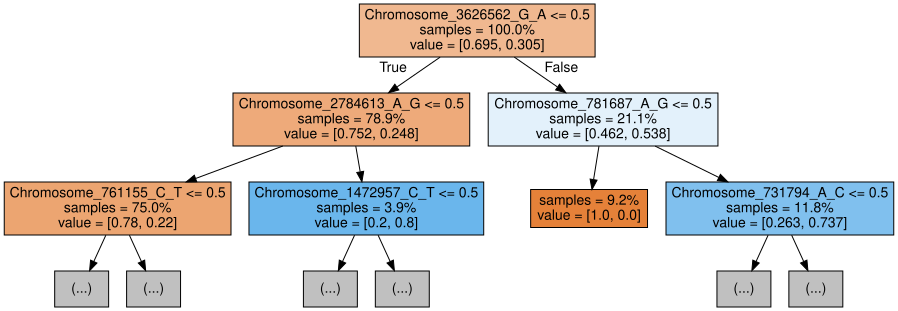

In [114]:
for i in range(3):
    tree = rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)
    graph.render(f"tree_{i}", format="png", cleanup=True)

## Pyrazinmide Resistance

In [125]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

PZA_na = input_df['pyrazinamide_resistance'].isna().sum()
print("Missing values before drop:", PZA_na)

Missing values before drop: 131


majority are missing - skipping

## Streptomycin Resistance

In [127]:
input_df = pd.read_csv("0_input.csv")
input_df = input_df.drop(columns=['id'], errors='ignore')

STM_na = input_df['streptomycin_resistance'].isna().sum()
print("Missing values before drop:", STM_na)

Missing values before drop: 127


majority are missing - skipping

<h4><center>END</center></h4>